# Stock/Bond Rebalancing flows

Trading the rebalancing flows of 60/40 portfolios. The strategy is long bonds if stocks outperformed the last month and long stocks if bonds outperformed.

Worked well until 2020. Maybe only go long when a certain level of outperformance happened?

In [98]:
import polars as pl
import datetime as dt
import numpy as np

df = (
    # uv run yf.py SPY TLT --output yf.parquet
    pl.read_parquet('yf.parquet')
    .select(
        date=pl.col("ts").dt.date(),
        symbol=pl.col("symbol").str.to_lowercase(),
        close=pl.col("close"),
    )
    .sort(["symbol", "date"])
    .with_columns(
        mtd=pl.col('close').log().diff(21),
        logret=pl.col('close').log().diff(),
    )
    .pivot(on='symbol', index='date')
    .drop_nulls()
    .with_columns(
        dir=pl.col('mtd_spy') - pl.col('mtd_tlt')
    )
    #.filter(pl.col('date').dt.year() >= 2003)
)

df

date,close_spy,close_tlt,mtd_spy,mtd_tlt,logret_spy,logret_tlt,dir
date,f32,f32,f32,f32,f32,f32,f32
2002-07-30,58.842659,36.24287,-0.084516,-2.915486,0.012949,-2.960752,2.83097
2002-07-31,58.98505,36.691879,-0.062404,-2.889122,0.002417,0.012313,2.826717
2002-08-01,57.445076,36.900845,-0.0674,-2.880975,-0.026454,0.005679,2.813576
2002-08-02,56.15744,37.278721,-0.095739,-2.856348,-0.02267,0.010188,2.760608
2002-08-05,54.203327,37.443214,-0.170172,-2.86239,-0.035417,0.004403,2.692218
…,…,…,…,…,…,…,…
2026-04-09,679.909973,86.699997,0.006751,-0.014072,0.005753,-0.002534,0.020823
2026-04-10,679.460022,86.489998,0.007345,-0.0035,-0.000662,-0.002425,0.010845
2026-04-13,686.099976,86.75,0.032371,0.001455,0.009725,0.003002,0.030916


open,close,value,price,shares,symbol,logret,ann
date,date,f64,f64,f64,str,f64,f64
2002-07-30,2002-08-15,1.055201,1.0,0.027592,"""tlt""",0.053731,2.330914
2002-08-15,2002-09-16,1.095591,1.055201,0.027592,"""tlt""",0.037563,1.34421
2002-09-16,2002-10-15,1.085933,1.095591,0.018836,"""spy""",-0.008854,0.925944
2002-10-15,2002-11-15,1.102853,1.085933,0.028121,"""tlt""",0.015461,1.133921
2002-11-15,2002-12-16,1.092247,1.102853,0.028121,"""tlt""",-0.009663,0.924453
…,…,…,…,…,…,…,…
2025-11-17,2025-12-15,5.194609,5.276212,0.060334,"""tlt""",-0.015587,0.869111
2025-12-15,2026-01-15,5.269122,5.194609,0.060334,"""tlt""",0.014242,1.122745
2026-01-15,2026-02-17,5.382712,5.269122,0.060334,"""tlt""",0.021329,1.176887


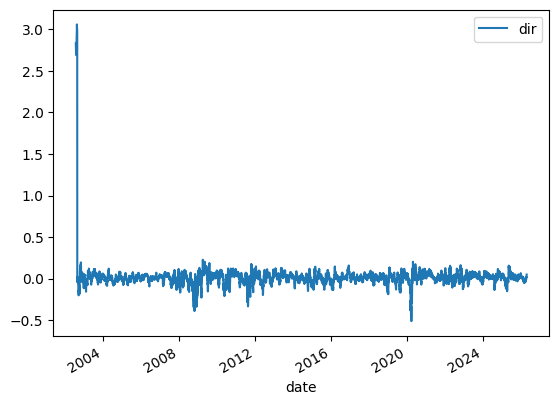

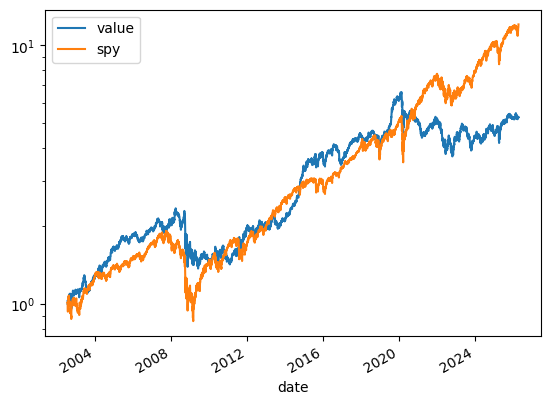

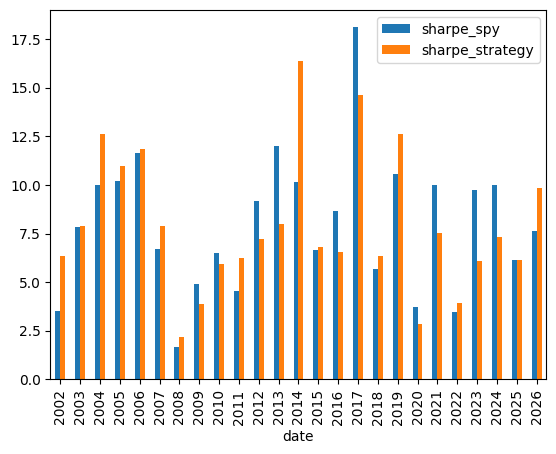

In [99]:
initial = 1.0
last_day = df['date'].max()

res_frag = []
pos_frag = []
folio = None
last_rebalance = None

for row in df.iter_rows(named=True):
    if folio is None:
        value = initial
    else:
        value = folio['shares'] * row[f'''close_{folio['symbol']}''']

    nrb = dt.datetime(row['date'].year, row['date'].month, 15).date()
    if last_rebalance is None or (row['date'] >= nrb and last_rebalance < nrb) or row['date'] >= last_day:
        # rebalance
        if folio is not None:
            pos_frag.append(pl.DataFrame({
                'open':folio['date'],
                'close':row['date'],
                'value':value,
                'price':folio['price'],
                'shares':folio['shares'],
                'symbol':folio['symbol'],
                'logret': np.log(value/folio['price']),
            }))

        if row['dir'] > 0:
            # spy outperformed MTD
            sym = 'tlt'
        else:
            # tlt outperformed MTD
            sym = 'spy'
        
        folio = {
            'date': row['date'],
            'symbol':sym,
            'price':value,
            'shares':value/row[f'close_{sym}'],
        }
        last_rebalance = row['date']

    value = folio['shares'] * row[f'''close_{folio['symbol']}''']
    res_frag.append(pl.DataFrame({
        'date':row['date'],
        'value':value,
    }))

res = (
    pl.concat(res_frag).join(df, on='date', how='inner')
    .with_columns(
        spy=pl.col('logret_spy').cum_sum().exp(),
        logret_strategy=pl.col('value').log().diff(),
    )
)
pos = pl.concat(pos_frag)

df.to_pandas().plot(y='dir', x='date')
res.to_pandas().plot(y=['value','spy'], x='date',logy=True)

(
    res.group_by(pl.col('date').dt.year())
    .agg(
        pl.col('logret_strategy').exp().mean().pow(252),
        pl.col('logret_spy').exp().mean().pow(252),
        std_strategy=pl.col('logret_strategy').exp().std() * np.sqrt(252),
        std_spy=pl.col('logret_spy').exp().std() * np.sqrt(252),
    )
    .sort('date')
    .with_columns(
        sharpe_strategy=pl.col('logret_strategy') / pl.col('std_strategy'),
        sharpe_spy=pl.col('logret_spy') / pl.col('std_spy'),
    )
    .to_pandas()
    .plot(kind='bar', y=['sharpe_spy','sharpe_strategy'], x='date')
)

(
    pos.with_columns(
        ann=pl.col('logret').exp().pow(252/(pl.col('close') - pl.col('open')).dt.total_days())
    )
)

In [127]:
from scipy.optimize import brute

def objective(params):
    a, b = params
    if a <= b:
        return np.inf
        
    return (
        df.filter(pl.col('date').dt.day() <= a)
        .group_by([
            pl.col('date').dt.year().alias('year'),
            pl.col('date').dt.month().alias('month')
        ], maintain_order=True)
        .last()
        .join_asof(
            df.filter(pl.col('date').dt.day() >= b)
            .group_by([
                pl.col('date').dt.year().alias('year'),
                pl.col('date').dt.month().alias('month')
            ], maintain_order=True)
            .first()
            .select(
                date=pl.col('date'),
                next_date=pl.col('date'),
                next_spy=pl.col('close_spy'),
                next_tlt=pl.col('close_tlt'),
            ), on="date", strategy="forward"
        )
        .select(['date','next_date','close_spy','close_tlt','next_spy','next_tlt','dir'])
        .with_columns(
            days=(pl.col('next_date') - pl.col('date')).dt.total_days(),
            logret=(
                pl.when(pl.col('dir') > 0)
                .then(pl.col('next_tlt').log() - pl.col('close_tlt').log())
                .otherwise(pl.col('next_spy').log() - pl.col('close_spy').log())
            ),
        )
        .with_columns(
            annret=pl.col('logret').exp().pow(356/pl.col('days')),
        )
        .select(
            ret=pl.col('annret').mean(),
            std=pl.col('annret').std()*np.sqrt(252),
        )
        .with_columns(
            sharpe=pl.col('ret')/pl.col('std'),
        )
    )['sharpe'][0] * -1

ranges = (slice(1, 31, 1), slice(1, 31, 1))
result = brute(objective, ranges, finish=None)
print(f"Optimal a: {result[0]}, Optimal b: {result[1]}")
-objective((result[0], result[1]))

Optimal a: 29.0, Optimal b: 27.0


0.15555460578599986